Now we will implement a Multiple Linear Regression

---


# Phase 1: Business Understanding & Problem Framing
Before writing code, define the business goal and translate it into a technical problem.
Define success: Set clear metrics (e.g., reduce customer churn by 5%, achieve 95% fraud detection).
Identify project type: Determine if it is a classification, regression, clustering, or generative AI problem.
Assess constraints: Check data availability, project budget, time limits, and hardware constraints.

# Phase 2: Data Collection & Ingestion
Gather the raw data required to solve the framed problem.
Identify sources: Locate databases, APIs, CSV files, web scraping targets, or IoT sensor streams.
Data storage: Store raw data securely in a data lake (e.g., AWS S3) or a data warehouse (e.g., Snowflake).
Data versioning: Use tools like DVC (Data Version Control) to track changes in your data files over time.

# Phase 3: Data Cleaning & Preprocessing
Prepare the raw data so that machine learning algorithms can read it without crashing.
Handle missing values: Drop columns with too many blanks, or fill them using averages (mean/median).
Fix data types: Convert text numbers to numeric types using pd.to_numeric(..., errors='coerce').
Remove duplicates: Clean out redundant rows to prevent model bias.
Manage outliers: Filter out extreme, corrupted data points that could distort model training.

# Phase 4: Exploratory Data Analysis (EDA)
Analyze the clean data visually and statistically to find patterns, anomalies, and relationships.
Check distributions: Plot histograms to see how target variables and features are spread out.
Correlation analysis: Create heatmaps to find which features correlate strongest with your target.
Visualize anomalies: Use scatter plots and box plots to spot hidden clusters or data shifts.

# Phase 5: Feature Engineering & Selection
Transform raw variables into highly informative features that boost model performance.
Encoding: Turn categorical text (like "Red", "Blue") into numbers using One-Hot or Label Encoding.
Scaling: Normalize numerical features to a uniform scale (e.g., 0 to 1) using StandardScaler or MinMaxScaler.
Feature creation: Combine columns to make new ones (e.g., dividing Distance by Time to create a Speed feature).
Feature selection: Drop highly redundant or useless features to keep the model fast and lightweight.

# Phase 6: Model Training & Hyperparameter Tuning
Train candidate models on your processed data to find the best-performing algorithm.
Data splitting: Divide your data into Training (70%), Validation (15%), and Testing (15%) sets.
Baseline training: Start with simple algorithms (e.g., Linear Regression, Decision Trees) to set a benchmark.
Hyperparameter tuning: Use LassoCV, GridSearchCV, or RandomizedSearchCV to fine-tune model settings and find optimal regularization strengths (alpha_).
Cross-Validation: Use K-Fold cross-validation to ensure model performance is stable across different data splits.

# Phase 7: Model Evaluation & Validation
Test the finalized model on unseen data to ensure it generalizes well to the real world.
Classification metrics: Check Accuracy, Precision, Recall, F1-Score, and the ROC-AUC score.
Regression metrics: Evaluate Mean Absolute Error (MAE), Mean Squared Error (MSE), and \(R^{2}\) Score.
Overfitting check: Compare training performance against testing performance to ensure the model didn't just memorize the training data.

# Phase 8: Model Deployment
Move the trained model out of your notebook and into a production environment where users can access it.
Model serialization: Save the trained model object as a file using pickle or joblib.
API creation: Wrap the model file in a web framework like FastAPI or Flask to accept data requests.
Containerization: Pack the API, model, and code dependencies into a Docker container for consistent deployment.
Cloud hosting: Deploy the container to a cloud platform (AWS, Google Cloud, Azure) or an ML platform (Hugging Face, SageMaker).

# Phase 9: Monitoring & Maintenance
Track the model's health in production and update it when real-world conditions change.
Monitor performance: Track latency (speed), system errors, and prediction distributions.
Detect Data Drift: Watch for shifts in incoming real-world data compared to the historical training data.
CI/CD retraining pipelines: Set up automated scripts to retrain and redeploy the model periodically with fresh data.

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
california=fetch_california_housing()
type(california)
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [ ]:
california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [ ]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
california.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [ ]:
california.target_names

['MedHouseVal']

In [ ]:
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [ ]:
california.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [ ]:
#Let prepare the dataset
df=pd.DataFrame(data=california.data,columns=california.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
df['Price']=california.target

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
#If has any null value
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: >

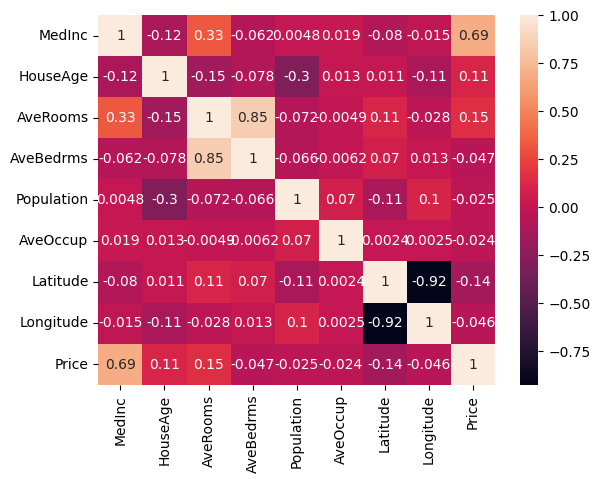

In [ ]:
sns.heatmap(df.corr(),annot=True)

In [ ]:
#Define the independent and dependent variable
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [ ]:
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
y.head()

,Price
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


# **Train_test_split**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=10)
x_train.shape,x_test.shape,y_train.shape,y_test.shape


((13828, 8), (6812, 8), (13828,), (6812,))

# **Standarized**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
x_test,x_train

(array([[ 0.75154854, -1.31428337, -0.39376169, ...,  0.12606697,
         -0.68820027,  0.19491761],
        [ 0.05935857, -0.12595418, -0.33070668, ..., -0.12021013,
          0.89459042, -1.36503888],
        [ 0.34405687, -1.31428337, -0.41007104, ..., -0.15581759,
         -0.91698123,  0.89764561],
        ...,
        [ 0.36483158,  0.27015554,  0.04216837, ..., -0.08014641,
         -0.46875731, -0.43803598],
        [-0.90412152, -0.91817364,  0.66736933, ..., -0.10263685,
          2.51006411, -1.96808915],
        [-0.43377577,  1.22081889, -0.44835491, ...,  0.2807072 ,
         -0.74422826,  0.69330627]]),
 array([[-0.72986836,  1.22081889, -0.70305988, ...,  0.05861244,
          0.96929441, -1.43979718],
        [-0.61046678, -0.28439808,  0.07828001, ...,  0.13015917,
         -0.75823526,  1.08204942],
        [ 0.00784578, -0.60128586, -0.2447376 , ..., -0.09793279,
          0.94594941, -1.2454256 ],
        ...,
        [ 0.88684913, -1.78961504, -0.21300658, ...,  

# **Train the Model**

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
model.coef_

array([ 0.82872299,  0.1231163 , -0.27068752,  0.32859106,  0.00213572,
       -0.02810091, -0.93017985, -0.89505497])

In [ ]:
model.intercept_

np.float64(2.0634768086491184)

In [ ]:
##Prediction for thr test data
y_pred=model.predict(x_test)
y_pred

array([3.00397485, 2.58011486, 2.3489077 , ..., 3.09003708, 0.79152007,
       2.04477012])

# **Performance Metrics**

In [ ]:
#R square and adjusted R square
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print('R2 Score',r2_score(y_test,y_pred))
print("Ajdusted R square",1-(1-r2_score(y_test,y_pred))*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))
print('MAE',mean_absolute_error(y_test,y_pred))
print('MSE',mean_squared_error(y_test,y_pred))

R2 Score 0.593595852643664
Ajdusted R square 0.5931179409607519
MAE 0.5371056943007959
MSE 0.5522332399363619


# **Assumption**

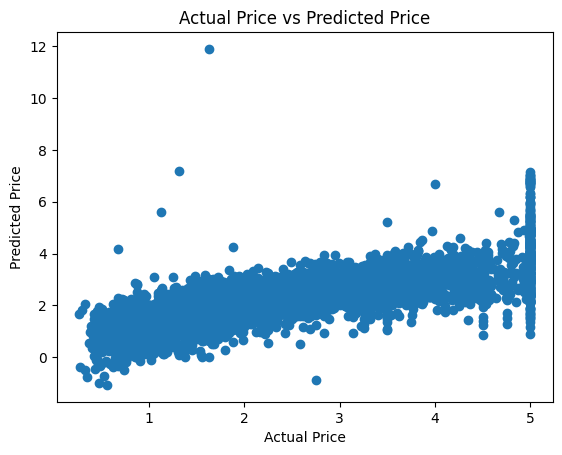

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Price vs Predicted Price')
plt.show()

**This is show the linear strcutrure .This is the well models**

In [ ]:
residuals=y_test-y_pred
residuals

,Price
20303,-1.329975
16966,0.960885
10623,-0.746908
6146,-0.307462
2208,-0.662167
...,...
13490,-0.243475
9340,0.507182
17439,-1.366037
2602,0.046480


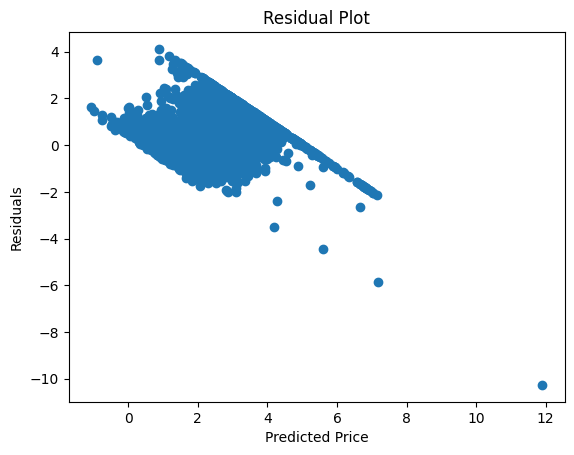

In [ ]:
plt.scatter(y_pred,residuals)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

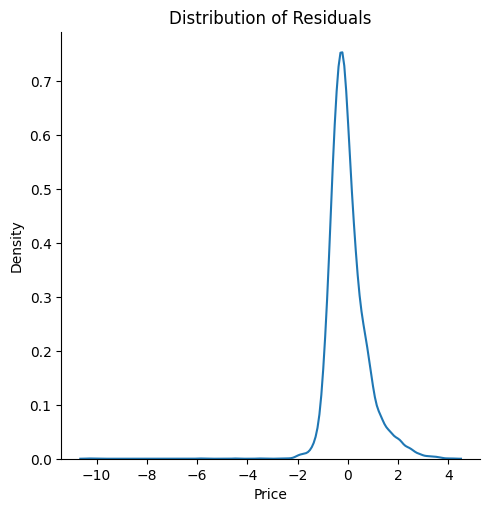

In [ ]:
sns.displot(residuals,kind='kde')
plt.title('Distribution of Residuals')
plt.show()

In the context of Python and Machine Learning, Pickling is the process of converting a Python object (like your trained linear regression model) into a byte stream so it can be saved to your hard drive, transferred, or deployed later.The reverse process—converting those saved bytes back into a working Python object—is called Unpickling.


**Why Use Pickling in Machine Learning?**

  1.Save Training Time: Training a model can take hours or days. Pickling lets you save the final trained model instantly so you never have to retrain it from scratch.

  
  2.Model Deployment: You can train a model in a Jupyter Notebook, pickle it into a file, and upload it to a production server (like a Flask or FastAPI web app) to make live predictions.

In [ ]:
import pickle
pickle.dump(model,open('model.pkl','wb'))

In [ ]:
model=pickle.load(open('model.pkl','rb'))

In [ ]:
model.predict(x_test)

array([3.00397485, 2.58011486, 2.3489077 , ..., 3.09003708, 0.79152007,
       2.04477012])